In [ ]:
!gcc --version

gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0
Copyright (C) 2023 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.



In [ ]:
%%writefile main.c
#include <stdio.h>

int main() {
    printf("AVL Tree Project - C\n");
    return 0;
}

Overwriting main.c


In [ ]:
!gcc main.c -o main

In [ ]:
!./main

AVL Tree Project - C


In [ ]:
%%writefile dataset.c

#include <stdio.h>
#include <stdlib.h>
#include <time.h>

int main() {

    int sizes[] = {100, 500, 1000, 5000, 10000, 20000};
    int count = 6;

    srand(time(NULL));

    for (int s = 0; s < count; s++) {

        int n = sizes[s];

        char randomFile[50];
        char ascendingFile[50];
        char descendingFile[50];

        sprintf(randomFile, "random_%d.txt", n);
        sprintf(ascendingFile, "ascending_%d.txt", n);
        sprintf(descendingFile, "descending_%d.txt", n);

        FILE *random = fopen(randomFile, "w");
        FILE *ascending = fopen(ascendingFile, "w");
        FILE *descending = fopen(descendingFile, "w");

        if (random == NULL || ascending == NULL || descending == NULL) {
            printf("Error creating files!\n");
            return 1;
        }

        /* Ascending and descending data */
        for (int i = 1; i <= n; i++) {
            fprintf(ascending, "%d\n", i);
            fprintf(descending, "%d\n", n - i + 1);
        }

        /* Create random data */
        int *data = malloc(n * sizeof(int));

        for (int i = 0; i < n; i++) {
            data[i] = i + 1;
        }

        /* Shuffle */
        for (int i = n - 1; i > 0; i--) {

            int j = rand() % (i + 1);

            int temp = data[i];
            data[i] = data[j];
            data[j] = temp;
        }

        for (int i = 0; i < n; i++) {
            fprintf(random, "%d\n", data[i]);
        }

        free(data);

        fclose(random);
        fclose(ascending);
        fclose(descending);

        printf("Created datasets for %d elements\n", n);
    }

    printf("\nAll datasets generated successfully!\n");

    return 0;
}

Overwriting dataset.c


In [ ]:
!gcc dataset.c -o dataset_program

In [ ]:
!./dataset_program

Created datasets for 100 elements
Created datasets for 500 elements
Created datasets for 1000 elements
Created datasets for 5000 elements
Created datasets for 10000 elements
Created datasets for 20000 elements

All datasets generated successfully!


In [ ]:
!ls *.txt

ascending_10000.txt  descending_10000.txt  random_10000.txt
ascending_1000.txt   descending_1000.txt   random_1000.txt
ascending_100.txt    descending_100.txt    random_100.txt
ascending_20000.txt  descending_20000.txt  random_20000.txt
ascending_5000.txt   descending_5000.txt   random_5000.txt
ascending_500.txt    descending_500.txt    random_500.txt


In [ ]:
%%writefile bst.c

#include <stdio.h>
#include <stdlib.h>

/* Structure of a BST node */
struct Node {
    int key;
    struct Node *left;
    struct Node *right;
};

/* Create a new node */
struct Node* createNode(int key) {

    struct Node* newNode =
        (struct Node*)malloc(sizeof(struct Node));

    newNode->key = key;
    newNode->left = NULL;
    newNode->right = NULL;

    return newNode;
}

/* Insert a key into the BST */
struct Node* insert(struct Node* root, int key) {

    if (root == NULL) {
        return createNode(key);
    }

    if (key < root->key) {
        root->left = insert(root->left, key);
    }
    else if (key > root->key) {
        root->right = insert(root->right, key);
    }

    return root;
}

/* Search for a key */
struct Node* search(struct Node* root, int key) {

    if (root == NULL || root->key == key) {
        return root;
    }

    if (key < root->key) {
        return search(root->left, key);
    }

    return search(root->right, key);
}

/* Inorder traversal */
void inorder(struct Node* root) {

    if (root != NULL) {
        inorder(root->left);
        printf("%d ", root->key);
        inorder(root->right);
    }
}

/* Free memory */
void freeTree(struct Node* root) {

    if (root != NULL) {
        freeTree(root->left);
        freeTree(root->right);
        free(root);
    }
}

int main() {

    struct Node* root = NULL;

    int values[] = {50, 30, 70, 20, 40, 60, 80};

    int n = sizeof(values) / sizeof(values[0]);

    /* Insert values */
    for (int i = 0; i < n; i++) {
        root = insert(root, values[i]);
    }

    printf("BST Inorder Traversal:\n");

    inorder(root);

    printf("\n");

    /* Search */
    int target = 40;

    if (search(root, target) != NULL) {
        printf("Element %d found in BST\n", target);
    }
    else {
        printf("Element %d not found in BST\n", target);
    }

    freeTree(root);

    return 0;
}

Writing bst.c


In [ ]:
!gcc bst.c -o bst

In [ ]:
!./bst

BST Inorder Traversal:
20 30 40 50 60 70 80 
Element 40 found in BST


In [ ]:
%%writefile bst.c

#include <stdio.h>
#include <stdlib.h>

struct Node {
    int key;
    struct Node *left;
    struct Node *right;
};

struct Node* createNode(int key) {

    struct Node* newNode =
        (struct Node*)malloc(sizeof(struct Node));

    newNode->key = key;
    newNode->left = NULL;
    newNode->right = NULL;

    return newNode;
}

struct Node* insert(struct Node* root, int key) {

    if (root == NULL) {
        return createNode(key);
    }

    if (key < root->key) {
        root->left = insert(root->left, key);
    }
    else if (key > root->key) {
        root->right = insert(root->right, key);
    }

    return root;
}

struct Node* search(struct Node* root, int key) {

    if (root == NULL || root->key == key) {
        return root;
    }

    if (key < root->key) {
        return search(root->left, key);
    }

    return search(root->right, key);
}

/* Calculate the height of the BST */
int height(struct Node* root) {

    if (root == NULL) {
        return 0;
    }

    int leftHeight = height(root->left);
    int rightHeight = height(root->right);

    if (leftHeight > rightHeight) {
        return leftHeight + 1;
    }
    else {
        return rightHeight + 1;
    }
}

void inorder(struct Node* root) {

    if (root != NULL) {
        inorder(root->left);
        printf("%d ", root->key);
        inorder(root->right);
    }
}

void freeTree(struct Node* root) {

    if (root != NULL) {
        freeTree(root->left);
        freeTree(root->right);
        free(root);
    }
}

int main() {

    struct Node* root = NULL;

    int values[] = {50, 30, 70, 20, 40, 60, 80};

    int n = sizeof(values) / sizeof(values[0]);

    for (int i = 0; i < n; i++) {
        root = insert(root, values[i]);
    }

    printf("BST Inorder Traversal:\n");
    inorder(root);

    printf("\n");

    int target = 40;

    if (search(root, target) != NULL) {
        printf("Element %d found in BST\n", target);
    }
    else {
        printf("Element %d not found in BST\n", target);
    }

    printf("BST Height: %d\n", height(root));

    freeTree(root);

    return 0;
}

Overwriting bst.c


In [ ]:
!gcc bst.c -o bst

In [ ]:
!./bst

BST Inorder Traversal:
20 30 40 50 60 70 80 
Element 40 found in BST
BST Height: 3


In [ ]:
%%writefile avl.c

#include <stdio.h>
#include <stdlib.h>

struct Node {
    int key;
    int height;
    struct Node *left;
    struct Node *right;
};

/* Get height of a node */
int height(struct Node *node) {
    if (node == NULL)
        return 0;

    return node->height;
}

/* Find maximum of two numbers */
int max(int a, int b) {
    return (a > b) ? a : b;
}

/* Create a new AVL node */
struct Node* createNode(int key) {

    struct Node* newNode =
        (struct Node*)malloc(sizeof(struct Node));

    newNode->key = key;
    newNode->height = 1;
    newNode->left = NULL;
    newNode->right = NULL;

    return newNode;
}

/* Calculate balance factor */
int getBalance(struct Node *node) {

    if (node == NULL)
        return 0;

    return height(node->left) - height(node->right);
}

/* Right Rotation - LL case */
struct Node* rightRotate(struct Node *y) {

    struct Node *x = y->left;
    struct Node *T2 = x->right;

    x->right = y;
    y->left = T2;

    y->height = 1 + max(height(y->left), height(y->right));
    x->height = 1 + max(height(x->left), height(x->right));

    return x;
}

/* Left Rotation - RR case */
struct Node* leftRotate(struct Node *x) {

    struct Node *y = x->right;
    struct Node *T2 = y->left;

    y->left = x;
    x->right = T2;

    x->height = 1 + max(height(x->left), height(x->right));
    y->height = 1 + max(height(y->left), height(y->right));

    return y;
}

/* Insert a key into AVL tree */
struct Node* insert(struct Node* node, int key) {

    if (node == NULL)
        return createNode(key);

    if (key < node->key)
        node->left = insert(node->left, key);

    else if (key > node->key)
        node->right = insert(node->right, key);

    else
        return node;

    /* Update height */
    node->height =
        1 + max(height(node->left), height(node->right));

    /* Check balance */
    int balance = getBalance(node);

    /* LL case */
    if (balance > 1 && key < node->left->key)
        return rightRotate(node);

    /* RR case */
    if (balance < -1 && key > node->right->key)
        return leftRotate(node);

    /* LR case */
    if (balance > 1 && key > node->left->key) {
        node->left = leftRotate(node->left);
        return rightRotate(node);
    }

    /* RL case */
    if (balance < -1 && key < node->right->key) {
        node->right = rightRotate(node->right);
        return leftRotate(node);
    }

    return node;
}

/* Search */
struct Node* search(struct Node* root, int key) {

    if (root == NULL || root->key == key)
        return root;

    if (key < root->key)
        return search(root->left, key);

    return search(root->right, key);
}

/* Inorder traversal */
void inorder(struct Node* root) {

    if (root != NULL) {
        inorder(root->left);
        printf("%d ", root->key);
        inorder(root->right);
    }
}

/* Free memory */
void freeTree(struct Node* root) {

    if (root != NULL) {
        freeTree(root->left);
        freeTree(root->right);
        free(root);
    }
}

int main() {

    struct Node* root = NULL;

    int values[] = {50, 30, 70, 20, 40, 60, 80};

    int n = sizeof(values) / sizeof(values[0]);

    for (int i = 0; i < n; i++) {
        root = insert(root, values[i]);
    }

    printf("AVL Inorder Traversal:\n");
    inorder(root);

    printf("\n");

    int target = 40;

    if (search(root, target) != NULL)
        printf("Element %d found in AVL\n", target);
    else
        printf("Element %d not found in AVL\n", target);

    printf("AVL Height: %d\n", height(root));

    freeTree(root);

    return 0;
}

Writing avl.c


In [ ]:
!gcc avl.c -o avl

In [ ]:
!./avl

AVL Inorder Traversal:
20 30 40 50 60 70 80 
Element 40 found in AVL
AVL Height: 3


In [ ]:
%%writefile test_rotation.c

#include <stdio.h>
#include <stdlib.h>

struct Node {
    int key;
    int height;
    struct Node *left;
    struct Node *right;
};

int height(struct Node *node) {
    if (node == NULL)
        return 0;
    return node->height;
}

int max(int a, int b) {
    return (a > b) ? a : b;
}

struct Node* createNode(int key) {
    struct Node* node =
        (struct Node*)malloc(sizeof(struct Node));

    node->key = key;
    node->height = 1;
    node->left = NULL;
    node->right = NULL;

    return node;
}

int getBalance(struct Node *node) {
    if (node == NULL)
        return 0;

    return height(node->left) - height(node->right);
}

struct Node* rightRotate(struct Node *y) {

    struct Node *x = y->left;
    struct Node *T2 = x->right;

    x->right = y;
    y->left = T2;

    y->height =
        1 + max(height(y->left), height(y->right));

    x->height =
        1 + max(height(x->left), height(x->right));

    return x;
}

struct Node* insert(struct Node* node, int key) {

    if (node == NULL)
        return createNode(key);

    if (key < node->key)
        node->left = insert(node->left, key);

    else if (key > node->key)
        node->right = insert(node->right, key);

    node->height =
        1 + max(height(node->left), height(node->right));

    int balance = getBalance(node);

    /* LL case */
    if (balance > 1 && key < node->left->key)
        return rightRotate(node);

    return node;
}

void inorder(struct Node* root) {

    if (root != NULL) {
        inorder(root->left);
        printf("%d ", root->key);
        inorder(root->right);
    }
}

int main() {

    struct Node* root = NULL;

    /* LL case */
    root = insert(root, 30);
    root = insert(root, 20);
    root = insert(root, 10);

    printf("Inorder after LL rotation:\n");
    inorder(root);

    printf("\nRoot: %d\n", root->key);
    printf("Height: %d\n", height(root));

    return 0;
}

Writing test_rotation.c


In [ ]:
!gcc test_rotation.c -o test_rotation

In [ ]:
!./test_rotation

Inorder after LL rotation:
10 20 30 
Root: 20
Height: 2


In [ ]:
%%writefile test_rr.c

#include <stdio.h>
#include <stdlib.h>

struct Node {
    int key;
    int height;
    struct Node *left;
    struct Node *right;
};

int height(struct Node *node) {
    if (node == NULL)
        return 0;
    return node->height;
}

int max(int a, int b) {
    return (a > b) ? a : b;
}

struct Node* createNode(int key) {

    struct Node* node =
        (struct Node*)malloc(sizeof(struct Node));

    node->key = key;
    node->height = 1;
    node->left = NULL;
    node->right = NULL;

    return node;
}

int getBalance(struct Node *node) {

    if (node == NULL)
        return 0;

    return height(node->left) - height(node->right);
}

struct Node* leftRotate(struct Node *x) {

    struct Node *y = x->right;
    struct Node *T2 = y->left;

    y->left = x;
    x->right = T2;

    x->height =
        1 + max(height(x->left), height(x->right));

    y->height =
        1 + max(height(y->left), height(y->right));

    return y;
}

struct Node* insert(struct Node* node, int key) {

    if (node == NULL)
        return createNode(key);

    if (key < node->key)
        node->left = insert(node->left, key);

    else if (key > node->key)
        node->right = insert(node->right, key);

    node->height =
        1 + max(height(node->left), height(node->right));

    int balance = getBalance(node);

    /* RR case */
    if (balance < -1 && key > node->right->key)
        return leftRotate(node);

    return node;
}

void inorder(struct Node* root) {

    if (root != NULL) {
        inorder(root->left);
        printf("%d ", root->key);
        inorder(root->right);
    }
}

int main() {

    struct Node* root = NULL;

    /* RR case */
    root = insert(root, 10);
    root = insert(root, 20);
    root = insert(root, 30);

    printf("Inorder after RR rotation:\n");
    inorder(root);

    printf("\nRoot: %d\n", root->key);
    printf("Height: %d\n", height(root));

    return 0;
}

Writing test_rr.c


In [ ]:
!gcc test_rr.c -o test_rr

In [ ]:
!./test_rr

Inorder after RR rotation:
10 20 30 
Root: 20
Height: 2


In [ ]:
%%writefile test_lr.c

#include <stdio.h>
#include <stdlib.h>

struct Node {
    int key;
    int height;
    struct Node *left;
    struct Node *right;
};

int height(struct Node *node) {
    if (node == NULL)
        return 0;
    return node->height;
}

int max(int a, int b) {
    return (a > b) ? a : b;
}

struct Node* createNode(int key) {

    struct Node* node =
        (struct Node*)malloc(sizeof(struct Node));

    node->key = key;
    node->height = 1;
    node->left = NULL;
    node->right = NULL;

    return node;
}

int getBalance(struct Node *node) {

    if (node == NULL)
        return 0;

    return height(node->left) - height(node->right);
}

struct Node* rightRotate(struct Node *y) {

    struct Node *x = y->left;
    struct Node *T2 = x->right;

    x->right = y;
    y->left = T2;

    y->height =
        1 + max(height(y->left), height(y->right));

    x->height =
        1 + max(height(x->left), height(x->right));

    return x;
}

struct Node* leftRotate(struct Node *x) {

    struct Node *y = x->right;
    struct Node *T2 = y->left;

    y->left = x;
    x->right = T2;

    x->height =
        1 + max(height(x->left), height(x->right));

    y->height =
        1 + max(height(y->left), height(y->right));

    return y;
}

struct Node* insert(struct Node* node, int key) {

    if (node == NULL)
        return createNode(key);

    if (key < node->key)
        node->left = insert(node->left, key);

    else if (key > node->key)
        node->right = insert(node->right, key);

    node->height =
        1 + max(height(node->left), height(node->right));

    int balance = getBalance(node);

    /* LR case */
    if (balance > 1 && key > node->left->key) {
        node->left = leftRotate(node->left);
        return rightRotate(node);
    }

    return node;
}

void inorder(struct Node* root) {

    if (root != NULL) {
        inorder(root->left);
        printf("%d ", root->key);
        inorder(root->right);
    }
}

int main() {

    struct Node* root = NULL;

    /* LR case */
    root = insert(root, 30);
    root = insert(root, 10);
    root = insert(root, 20);

    printf("Inorder after LR rotation:\n");
    inorder(root);

    printf("\nRoot: %d\n", root->key);
    printf("Height: %d\n", height(root));

    return 0;
}

Writing test_lr.c


In [ ]:
!gcc test_lr.c -o test_lr

In [ ]:
!./test_lr

Inorder after LR rotation:
10 20 30 
Root: 20
Height: 2


In [ ]:
%%writefile test_rl.c

#include <stdio.h>
#include <stdlib.h>

struct Node {
    int key;
    int height;
    struct Node *left;
    struct Node *right;
};

int height(struct Node *node) {
    if (node == NULL)
        return 0;
    return node->height;
}

int max(int a, int b) {
    return (a > b) ? a : b;
}

struct Node* createNode(int key) {

    struct Node* node =
        (struct Node*)malloc(sizeof(struct Node));

    node->key = key;
    node->height = 1;
    node->left = NULL;
    node->right = NULL;

    return node;
}

int getBalance(struct Node *node) {

    if (node == NULL)
        return 0;

    return height(node->left) - height(node->right);
}

struct Node* rightRotate(struct Node *y) {

    struct Node *x = y->left;
    struct Node *T2 = x->right;

    x->right = y;
    y->left = T2;

    y->height =
        1 + max(height(y->left), height(y->right));

    x->height =
        1 + max(height(x->left), height(x->right));

    return x;
}

struct Node* leftRotate(struct Node *x) {

    struct Node *y = x->right;
    struct Node *T2 = y->left;

    y->left = x;
    x->right = T2;

    x->height =
        1 + max(height(x->left), height(x->right));

    y->height =
        1 + max(height(y->left), height(y->right));

    return y;
}

struct Node* insert(struct Node* node, int key) {

    if (node == NULL)
        return createNode(key);

    if (key < node->key)
        node->left = insert(node->left, key);

    else if (key > node->key)
        node->right = insert(node->right, key);

    node->height =
        1 + max(height(node->left), height(node->right));

    int balance = getBalance(node);

    /* RL case */
    if (balance < -1 && key < node->right->key) {
        node->right = rightRotate(node->right);
        return leftRotate(node);
    }

    return node;
}

void inorder(struct Node* root) {

    if (root != NULL) {
        inorder(root->left);
        printf("%d ", root->key);
        inorder(root->right);
    }
}

int main() {

    struct Node* root = NULL;

    /* RL case */
    root = insert(root, 10);
    root = insert(root, 30);
    root = insert(root, 20);

    printf("Inorder after RL rotation:\n");
    inorder(root);

    printf("\nRoot: %d\n", root->key);
    printf("Height: %d\n", height(root));

    return 0;
}

Writing test_rl.c


In [ ]:
!gcc test_rl.c -o test_rl

In [ ]:
!./test_rl

Inorder after RL rotation:
10 20 30 
Root: 20
Height: 2


In [ ]:
%%writefile bst_experiment.c

#include <stdio.h>
#include <stdlib.h>
#include <time.h>

struct Node {
    int key;
    struct Node *left;
    struct Node *right;
};

/* Create a new node */
struct Node* createNode(int key) {

    struct Node* newNode =
        (struct Node*)malloc(sizeof(struct Node));

    newNode->key = key;
    newNode->left = NULL;
    newNode->right = NULL;

    return newNode;
}

/* Iterative BST insertion */
struct Node* insert(struct Node* root, int key) {

    struct Node* newNode = createNode(key);

    if (root == NULL)
        return newNode;

    struct Node* current = root;
    struct Node* parent = NULL;

    while (current != NULL) {

        parent = current;

        if (key < current->key)
            current = current->left;
        else if (key > current->key)
            current = current->right;
        else {
            free(newNode);
            return root;
        }
    }

    if (key < parent->key)
        parent->left = newNode;
    else
        parent->right = newNode;

    return root;
}

/* Calculate tree height without recursion */
int height(struct Node* root) {

    if (root == NULL)
        return 0;

    int maxHeight = 0;

    struct Node** queue =
        (struct Node**)malloc(20001 * sizeof(struct Node*));

    int front = 0;
    int rear = 0;

    queue[rear++] = root;

    while (front < rear) {

        int levelSize = rear - front;
        maxHeight++;

        for (int i = 0; i < levelSize; i++) {

            struct Node* current = queue[front++];

            if (current->left != NULL)
                queue[rear++] = current->left;

            if (current->right != NULL)
                queue[rear++] = current->right;
        }
    }

    free(queue);

    return maxHeight;
}

/* Free the tree */
void freeTree(struct Node* root) {

    if (root == NULL)
        return;

    freeTree(root->left);
    freeTree(root->right);

    free(root);
}

/* Read dataset from file */
int* readDataset(const char* filename, int n) {

    FILE* file = fopen(filename, "r");

    if (file == NULL) {
        printf("Cannot open %s\n", filename);
        return NULL;
    }

    int* data = (int*)malloc(n * sizeof(int));

    for (int i = 0; i < n; i++)
        fscanf(file, "%d", &data[i]);

    fclose(file);

    return data;
}

int main() {

    int sizes[] = {
        100, 500, 1000,
        5000, 10000, 20000
    };

    char* types[] = {
        "random",
        "ascending",
        "descending"
    };

    int numberOfSizes = 6;
    int numberOfTypes = 3;

    for (int t = 0; t < numberOfTypes; t++) {

        for (int s = 0; s < numberOfSizes; s++) {

            int n = sizes[s];

            char filename[100];

            sprintf(filename, "%s_%d.txt",
                    types[t], n);

            int* data = readDataset(filename, n);

            if (data == NULL)
                return 1;

            struct Node* root = NULL;

            clock_t start = clock();

            for (int i = 0; i < n; i++)
                root = insert(root, data[i]);

            clock_t end = clock();

            double insertionTime =
                (double)(end - start) / CLOCKS_PER_SEC;

            int treeHeight = height(root);

            printf("%s | N=%d | Height=%d | Insert Time=%.6f sec\n",
                   types[t],
                   n,
                   treeHeight,
                   insertionTime);

            freeTree(root);
            free(data);
        }
    }

    return 0;
}

Writing bst_experiment.c


In [ ]:
!gcc bst_experiment.c -o bst_experiment

In [ ]:
!./bst_experiment

random | N=100 | Height=13 | Insert Time=0.000018 sec
random | N=500 | Height=16 | Insert Time=0.000104 sec
random | N=1000 | Height=21 | Insert Time=0.000222 sec
random | N=5000 | Height=27 | Insert Time=0.001420 sec
random | N=10000 | Height=31 | Insert Time=0.002604 sec
random | N=20000 | Height=34 | Insert Time=0.005612 sec
ascending | N=100 | Height=100 | Insert Time=0.000037 sec
ascending | N=500 | Height=500 | Insert Time=0.000848 sec
ascending | N=1000 | Height=1000 | Insert Time=0.003226 sec
ascending | N=5000 | Height=5000 | Insert Time=0.080685 sec
ascending | N=10000 | Height=10000 | Insert Time=0.320690 sec
ascending | N=20000 | Height=20000 | Insert Time=1.396693 sec
descending | N=100 | Height=100 | Insert Time=0.000041 sec
descending | N=500 | Height=500 | Insert Time=0.000859 sec
descending | N=1000 | Height=1000 | Insert Time=0.003396 sec
descending | N=5000 | Height=5000 | Insert Time=0.082457 sec
descending | N=10000 | Height=10000 | Insert Time=0.327346 sec
descend

In [ ]:
%%writefile avl_experiment.c

#include <stdio.h>
#include <stdlib.h>
#include <time.h>

struct Node {
    int key;
    int height;
    struct Node *left;
    struct Node *right;
};

/* Get node height */
int height(struct Node *node) {
    if (node == NULL)
        return 0;

    return node->height;
}

/* Maximum of two numbers */
int max(int a, int b) {
    return (a > b) ? a : b;
}

/* Create a new node */
struct Node* createNode(int key) {

    struct Node* node =
        (struct Node*)malloc(sizeof(struct Node));

    node->key = key;
    node->height = 1;
    node->left = NULL;
    node->right = NULL;

    return node;
}

/* Get balance factor */
int getBalance(struct Node *node) {

    if (node == NULL)
        return 0;

    return height(node->left) - height(node->right);
}

/* Right rotation */
struct Node* rightRotate(struct Node *y) {

    struct Node *x = y->left;
    struct Node *T2 = x->right;

    x->right = y;
    y->left = T2;

    y->height =
        1 + max(height(y->left), height(y->right));

    x->height =
        1 + max(height(x->left), height(x->right));

    return x;
}

/* Left rotation */
struct Node* leftRotate(struct Node *x) {

    struct Node *y = x->right;
    struct Node *T2 = y->left;

    y->left = x;
    x->right = T2;

    x->height =
        1 + max(height(x->left), height(x->right));

    y->height =
        1 + max(height(y->left), height(y->right));

    return y;
}

/* AVL insertion */
struct Node* insert(struct Node* node, int key) {

    if (node == NULL)
        return createNode(key);

    if (key < node->key)
        node->left = insert(node->left, key);

    else if (key > node->key)
        node->right = insert(node->right, key);

    else
        return node;

    /* Update height */
    node->height =
        1 + max(height(node->left), height(node->right));

    /* Check balance */
    int balance = getBalance(node);

    /* LL */
    if (balance > 1 && key < node->left->key)
        return rightRotate(node);

    /* RR */
    if (balance < -1 && key > node->right->key)
        return leftRotate(node);

    /* LR */
    if (balance > 1 && key > node->left->key) {
        node->left = leftRotate(node->left);
        return rightRotate(node);
    }

    /* RL */
    if (balance < -1 && key < node->right->key) {
        node->right = rightRotate(node->right);
        return leftRotate(node);
    }

    return node;
}

/* Free tree */
void freeTree(struct Node* root) {

    if (root == NULL)
        return;

    freeTree(root->left);
    freeTree(root->right);

    free(root);
}

/* Read dataset */
int* readDataset(const char* filename, int n) {

    FILE* file = fopen(filename, "r");

    if (file == NULL) {
        printf("Cannot open %s\n", filename);
        return NULL;
    }

    int* data =
        (int*)malloc(n * sizeof(int));

    for (int i = 0; i < n; i++)
        fscanf(file, "%d", &data[i]);

    fclose(file);

    return data;
}

int main() {

    int sizes[] = {
        100, 500, 1000,
        5000, 10000, 20000
    };

    char* types[] = {
        "random",
        "ascending",
        "descending"
    };

    int numberOfSizes = 6;
    int numberOfTypes = 3;

    for (int t = 0; t < numberOfTypes; t++) {

        for (int s = 0; s < numberOfSizes; s++) {

            int n = sizes[s];

            char filename[100];

            sprintf(filename, "%s_%d.txt",
                    types[t], n);

            int* data =
                readDataset(filename, n);

            if (data == NULL)
                return 1;

            struct Node* root = NULL;

            clock_t start = clock();

            for (int i = 0; i < n; i++)
                root = insert(root, data[i]);

            clock_t end = clock();

            double insertionTime =
                (double)(end - start)
                / CLOCKS_PER_SEC;

            printf("%s | N=%d | Height=%d | Insert Time=%.6f sec\n",
                   types[t],
                   n,
                   height(root),
                   insertionTime);

            freeTree(root);
            free(data);
        }
    }

    return 0;
}

Writing avl_experiment.c


In [ ]:
!gcc avl_experiment.c -o avl_experiment

In [ ]:
!./avl_experiment

random | N=100 | Height=8 | Insert Time=0.000041 sec
random | N=500 | Height=11 | Insert Time=0.000247 sec
random | N=1000 | Height=12 | Insert Time=0.000534 sec
random | N=5000 | Height=15 | Insert Time=0.003196 sec
random | N=10000 | Height=16 | Insert Time=0.005698 sec
random | N=20000 | Height=17 | Insert Time=0.013250 sec
ascending | N=100 | Height=7 | Insert Time=0.000026 sec
ascending | N=500 | Height=9 | Insert Time=0.000147 sec
ascending | N=1000 | Height=10 | Insert Time=0.000319 sec
ascending | N=5000 | Height=13 | Insert Time=0.002043 sec
ascending | N=10000 | Height=14 | Insert Time=0.004701 sec
ascending | N=20000 | Height=15 | Insert Time=0.009824 sec
descending | N=100 | Height=7 | Insert Time=0.000024 sec
descending | N=500 | Height=9 | Insert Time=0.000140 sec
descending | N=1000 | Height=10 | Insert Time=0.000310 sec
descending | N=5000 | Height=13 | Insert Time=0.001964 sec
descending | N=10000 | Height=14 | Insert Time=0.004279 sec
descending | N=20000 | Height=15 

In [ ]:
!./bst_experiment > bst_results.txt

In [ ]:
!cat bst_results.txt

random | N=100 | Height=13 | Insert Time=0.000014 sec
random | N=500 | Height=16 | Insert Time=0.000083 sec
random | N=1000 | Height=21 | Insert Time=0.000176 sec
random | N=5000 | Height=27 | Insert Time=0.001154 sec
random | N=10000 | Height=31 | Insert Time=0.002524 sec
random | N=20000 | Height=34 | Insert Time=0.005605 sec
ascending | N=100 | Height=100 | Insert Time=0.000036 sec
ascending | N=500 | Height=500 | Insert Time=0.000837 sec
ascending | N=1000 | Height=1000 | Insert Time=0.003128 sec
ascending | N=5000 | Height=5000 | Insert Time=0.079709 sec
ascending | N=10000 | Height=10000 | Insert Time=0.318716 sec
ascending | N=20000 | Height=20000 | Insert Time=1.273368 sec
descending | N=100 | Height=100 | Insert Time=0.000035 sec
descending | N=500 | Height=500 | Insert Time=0.000734 sec
descending | N=1000 | Height=1000 | Insert Time=0.002910 sec
descending | N=5000 | Height=5000 | Insert Time=0.073091 sec
descending | N=10000 | Height=10000 | Insert Time=0.296737 sec
descend

In [ ]:
!./avl_experiment > avl_results.txt

In [ ]:
!cat avl_results.txt

random | N=100 | Height=8 | Insert Time=0.000030 sec
random | N=500 | Height=11 | Insert Time=0.000182 sec
random | N=1000 | Height=12 | Insert Time=0.000435 sec
random | N=5000 | Height=15 | Insert Time=0.002634 sec
random | N=10000 | Height=16 | Insert Time=0.005641 sec
random | N=20000 | Height=17 | Insert Time=0.012647 sec
ascending | N=100 | Height=7 | Insert Time=0.000025 sec
ascending | N=500 | Height=9 | Insert Time=0.000146 sec
ascending | N=1000 | Height=10 | Insert Time=0.000327 sec
ascending | N=5000 | Height=13 | Insert Time=0.002010 sec
ascending | N=10000 | Height=14 | Insert Time=0.004433 sec
ascending | N=20000 | Height=15 | Insert Time=0.009854 sec
descending | N=100 | Height=7 | Insert Time=0.000024 sec
descending | N=500 | Height=9 | Insert Time=0.000138 sec
descending | N=1000 | Height=10 | Insert Time=0.000332 sec
descending | N=5000 | Height=13 | Insert Time=0.001993 sec
descending | N=10000 | Height=14 | Insert Time=0.004275 sec
descending | N=20000 | Height=15 

In [ ]:
import pandas as pd
import re

def read_results(filename, tree_name):
    rows = []

    with open(filename, "r") as file:
        for line in file:
            match = re.search(
                r"(random|ascending|descending) \| N=(\d+) \| Height=(\d+) \| Insert Time=([\d.]+)",
                line
            )

            if match:
                rows.append({
                    "Order": match.group(1),
                    "Size": int(match.group(2)),
                    f"{tree_name} Height": int(match.group(3)),
                    f"{tree_name} Insert Time": float(match.group(4))
                })

    return pd.DataFrame(rows)

bst = read_results("bst_results.txt", "BST")
avl = read_results("avl_results.txt", "AVL")

results = pd.merge(
    bst,
    avl,
    on=["Order", "Size"]
)

results = results[
    [
        "Size",
        "Order",
        "BST Height",
        "AVL Height",
        "BST Insert Time",
        "AVL Insert Time"
    ]
]

results = results.sort_values(
    ["Order", "Size"]
)

results

,Size,Order,BST Height,AVL Height,BST Insert Time,AVL Insert Time
6,100,ascending,100,7,0.000036,0.000025
7,500,ascending,500,9,0.000837,0.000146
8,1000,ascending,1000,10,0.003128,0.000327
9,5000,ascending,5000,13,0.079709,0.002010
10,10000,ascending,10000,14,0.318716,0.004433
11,20000,ascending,20000,15,1.273368,0.009854
12,100,descending,100,7,0.000035,0.000024
13,500,descending,500,9,0.000734,0.000138
14,1000,descending,1000,10,0.002910,0.000332
15,5000,descending,5000,13,0.073091,0.001993


In [ ]:
results.to_csv("avl_bst_results.csv", index=False)

print("Results saved successfully!")

Results saved successfully!


In [ ]:
from google.colab import files

files.download("avl_bst_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

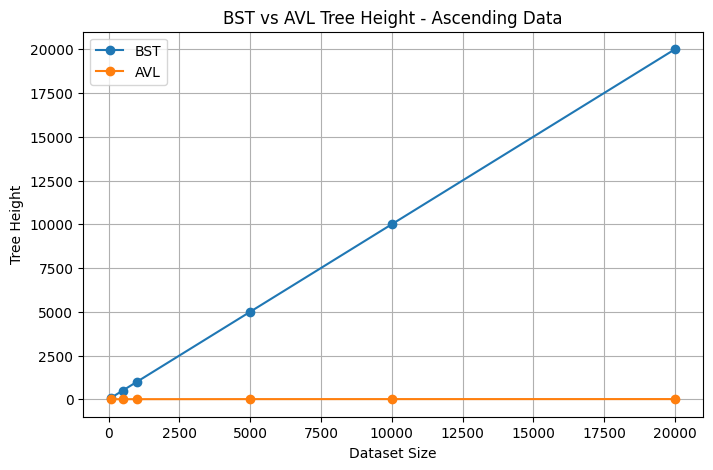

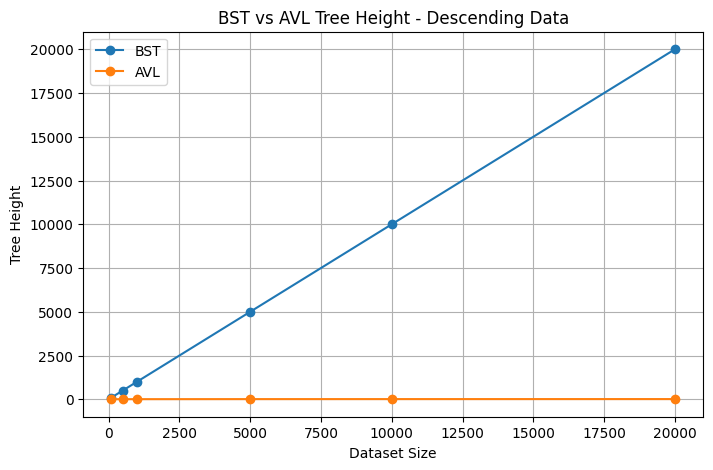

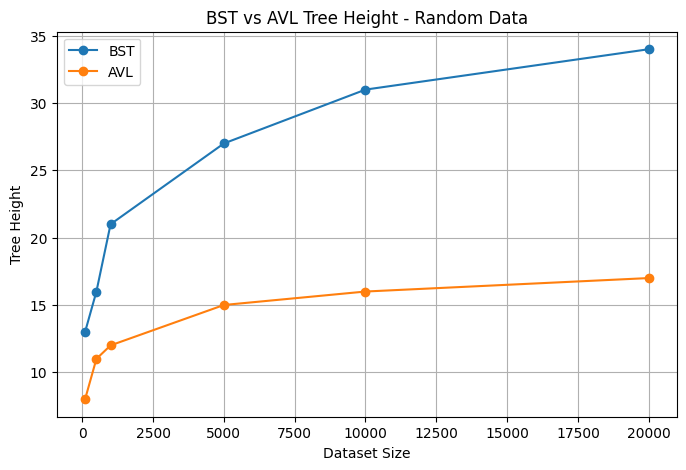

In [ ]:
import matplotlib.pyplot as plt

orders = ["ascending", "descending", "random"]

for order in orders:

    data = results[results["Order"] == order]

    plt.figure(figsize=(8, 5))

    plt.plot(
        data["Size"],
        data["BST Height"],
        marker="o",
        label="BST"
    )

    plt.plot(
        data["Size"],
        data["AVL Height"],
        marker="o",
        label="AVL"
    )

    plt.xlabel("Dataset Size")
    plt.ylabel("Tree Height")

    plt.title(
        f"BST vs AVL Tree Height - {order.capitalize()} Data"
    )

    plt.legend()
    plt.grid(True)

    plt.show()

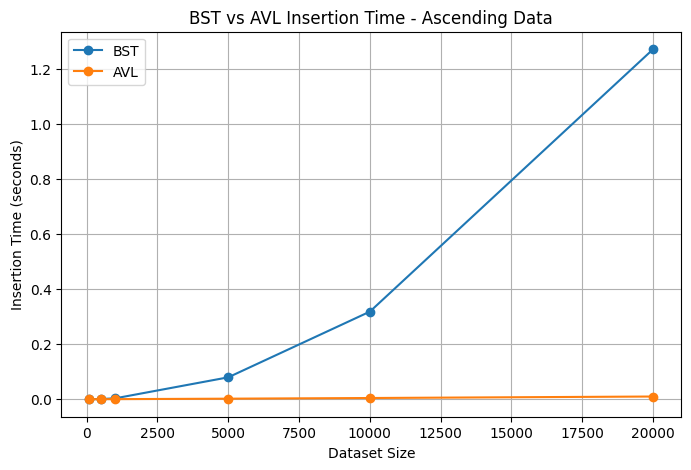

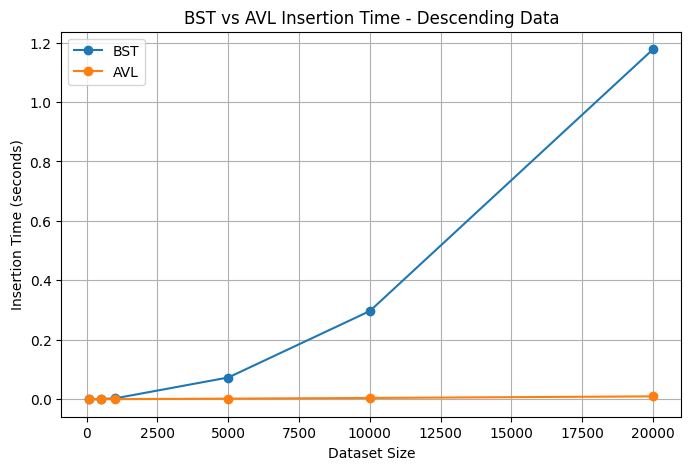

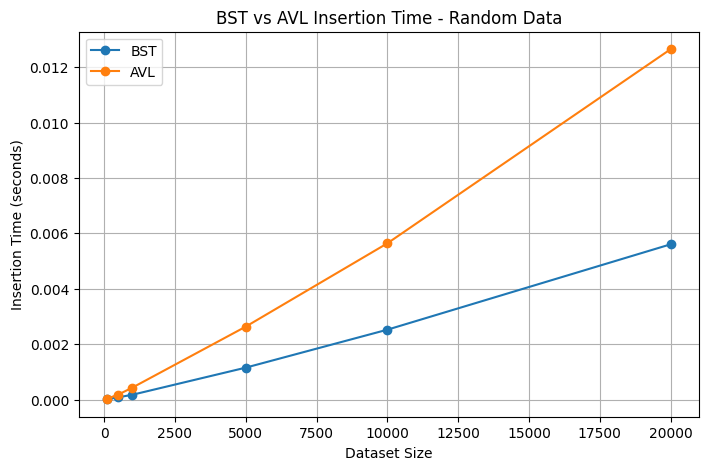

In [ ]:
import matplotlib.pyplot as plt

orders = ["ascending", "descending", "random"]

for order in orders:

    data = results[results["Order"] == order]

    plt.figure(figsize=(8, 5))

    plt.plot(
        data["Size"],
        data["BST Insert Time"],
        marker="o",
        label="BST"
    )

    plt.plot(
        data["Size"],
        data["AVL Insert Time"],
        marker="o",
        label="AVL"
    )

    plt.xlabel("Dataset Size")
    plt.ylabel("Insertion Time (seconds)")

    plt.title(
        f"BST vs AVL Insertion Time - {order.capitalize()} Data"
    )

    plt.legend()
    plt.grid(True)

    plt.show()

In [ ]:
%%writefile search_experiment.c

#include <stdio.h>
#include <stdlib.h>

struct Node {
    int key;
    int height;
    struct Node *left;
    struct Node *right;
};

/* ---------- BST ---------- */

struct Node* createNode(int key) {
    struct Node* node =
        (struct Node*)malloc(sizeof(struct Node));

    node->key = key;
    node->height = 1;
    node->left = NULL;
    node->right = NULL;

    return node;
}

struct Node* bstInsert(struct Node* root, int key) {

    if (root == NULL)
        return createNode(key);

    struct Node* current = root;
    struct Node* parent = NULL;

    while (current != NULL) {

        parent = current;

        if (key < current->key)
            current = current->left;

        else if (key > current->key)
            current = current->right;

        else
            return root;
    }

    if (key < parent->key)
        parent->left = createNode(key);
    else
        parent->right = createNode(key);

    return root;
}

/* ---------- AVL ---------- */

int height(struct Node* node) {
    if (node == NULL)
        return 0;

    return node->height;
}

int max(int a, int b) {
    return (a > b) ? a : b;
}

int balanceFactor(struct Node* node) {

    if (node == NULL)
        return 0;

    return height(node->left) - height(node->right);
}

struct Node* rightRotate(struct Node* y) {

    struct Node* x = y->left;
    struct Node* T2 = x->right;

    x->right = y;
    y->left = T2;

    y->height =
        1 + max(height(y->left), height(y->right));

    x->height =
        1 + max(height(x->left), height(x->right));

    return x;
}

struct Node* leftRotate(struct Node* x) {

    struct Node* y = x->right;
    struct Node* T2 = y->left;

    y->left = x;
    x->right = T2;

    x->height =
        1 + max(height(x->left), height(x->right));

    y->height =
        1 + max(height(y->left), height(y->right));

    return y;
}

struct Node* avlInsert(struct Node* node, int key) {

    if (node == NULL)
        return createNode(key);

    if (key < node->key)
        node->left = avlInsert(node->left, key);

    else if (key > node->key)
        node->right = avlInsert(node->right, key);

    else
        return node;

    node->height =
        1 + max(height(node->left), height(node->right));

    int balance = balanceFactor(node);

    if (balance > 1 && key < node->left->key)
        return rightRotate(node);

    if (balance < -1 && key > node->right->key)
        return leftRotate(node);

    if (balance > 1 && key > node->left->key) {
        node->left = leftRotate(node->left);
        return rightRotate(node);
    }

    if (balance < -1 && key < node->right->key) {
        node->right = rightRotate(node->right);
        return leftRotate(node);
    }

    return node;
}

/* ---------- Search comparison count ---------- */

int searchComparisons(struct Node* root, int target) {

    int comparisons = 0;

    struct Node* current = root;

    while (current != NULL) {

        comparisons++;

        if (current->key == target)
            return comparisons;

        if (target < current->key)
            current = current->left;
        else
            current = current->right;
    }

    return comparisons;
}

/* ---------- Read dataset ---------- */

int* readDataset(const char* filename, int n) {

    FILE* file = fopen(filename, "r");

    if (file == NULL) {
        printf("Cannot open %s\n", filename);
        return NULL;
    }

    int* data = malloc(n * sizeof(int));

    for (int i = 0; i < n; i++)
        fscanf(file, "%d", &data[i]);

    fclose(file);

    return data;
}

/* ---------- Free tree ---------- */

void freeTree(struct Node* root) {

    if (root == NULL)
        return;

    freeTree(root->left);
    freeTree(root->right);

    free(root);
}

/* ---------- Main ---------- */

int main() {

    int sizes[] = {
        100, 500, 1000,
        5000, 10000, 20000
    };

    char* types[] = {
        "random",
        "ascending",
        "descending"
    };

    for (int t = 0; t < 3; t++) {

        for (int s = 0; s < 6; s++) {

            int n = sizes[s];

            char filename[100];

            sprintf(
                filename,
                "%s_%d.txt",
                types[t],
                n
            );

            int* data = readDataset(filename, n);

            if (data == NULL)
                return 1;

            struct Node* bst = NULL;
            struct Node* avl = NULL;

            for (int i = 0; i < n; i++) {

                bst = bstInsert(bst, data[i]);

                avl = avlInsert(avl, data[i]);
            }

            /*
             * Search for the middle value.
             * It exists in every dataset.
             */

            int target = n / 2;

            int bstComparisons =
                searchComparisons(bst, target);

            int avlComparisons =
                searchComparisons(avl, target);

            printf(
                "%s | N=%d | BST Comparisons=%d | AVL Comparisons=%d\n",
                types[t],
                n,
                bstComparisons,
                avlComparisons
            );

            freeTree(bst);
            freeTree(avl);
            free(data);
        }
    }

    return 0;
}

Writing search_experiment.c


In [ ]:
!gcc search_experiment.c -o search_experiment

In [ ]:
!./search_experiment

random | N=100 | BST Comparisons=4 | AVL Comparisons=5
random | N=500 | BST Comparisons=14 | AVL Comparisons=10
random | N=1000 | BST Comparisons=12 | AVL Comparisons=11
random | N=5000 | BST Comparisons=19 | AVL Comparisons=12
random | N=10000 | BST Comparisons=17 | AVL Comparisons=13
random | N=20000 | BST Comparisons=18 | AVL Comparisons=12
ascending | N=100 | BST Comparisons=50 | AVL Comparisons=6
ascending | N=500 | BST Comparisons=250 | AVL Comparisons=8
ascending | N=1000 | BST Comparisons=500 | AVL Comparisons=8
ascending | N=5000 | BST Comparisons=2500 | AVL Comparisons=10
ascending | N=10000 | BST Comparisons=5000 | AVL Comparisons=10
ascending | N=20000 | BST Comparisons=10000 | AVL Comparisons=10
descending | N=100 | BST Comparisons=51 | AVL Comparisons=7
descending | N=500 | BST Comparisons=251 | AVL Comparisons=9
descending | N=1000 | BST Comparisons=501 | AVL Comparisons=10
descending | N=5000 | BST Comparisons=2501 | AVL Comparisons=12
descending | N=10000 | BST Compari

In [ ]:
!./search_experiment > search_results.txt

In [ ]:
!cat search_results.txt

random | N=100 | BST Comparisons=4 | AVL Comparisons=5
random | N=500 | BST Comparisons=14 | AVL Comparisons=10
random | N=1000 | BST Comparisons=12 | AVL Comparisons=11
random | N=5000 | BST Comparisons=19 | AVL Comparisons=12
random | N=10000 | BST Comparisons=17 | AVL Comparisons=13
random | N=20000 | BST Comparisons=18 | AVL Comparisons=12
ascending | N=100 | BST Comparisons=50 | AVL Comparisons=6
ascending | N=500 | BST Comparisons=250 | AVL Comparisons=8
ascending | N=1000 | BST Comparisons=500 | AVL Comparisons=8
ascending | N=5000 | BST Comparisons=2500 | AVL Comparisons=10
ascending | N=10000 | BST Comparisons=5000 | AVL Comparisons=10
ascending | N=20000 | BST Comparisons=10000 | AVL Comparisons=10
descending | N=100 | BST Comparisons=51 | AVL Comparisons=7
descending | N=500 | BST Comparisons=251 | AVL Comparisons=9
descending | N=1000 | BST Comparisons=501 | AVL Comparisons=10
descending | N=5000 | BST Comparisons=2501 | AVL Comparisons=12
descending | N=10000 | BST Compari

In [ ]:
import pandas as pd
import re

rows = []

with open("search_results.txt", "r") as file:
    for line in file:

        match = re.search(
            r"(random|ascending|descending) \| N=(\d+) \| BST Comparisons=(\d+) \| AVL Comparisons=(\d+)",
            line
        )

        if match:
            rows.append({
                "Order": match.group(1),
                "Size": int(match.group(2)),
                "BST Comparisons": int(match.group(3)),
                "AVL Comparisons": int(match.group(4))
            })

search_results = pd.DataFrame(rows)

search_results = search_results.sort_values(
    ["Order", "Size"]
)

search_results

,Order,Size,BST Comparisons,AVL Comparisons
6,ascending,100,50,6
7,ascending,500,250,8
8,ascending,1000,500,8
9,ascending,5000,2500,10
10,ascending,10000,5000,10
11,ascending,20000,10000,10
12,descending,100,51,7
13,descending,500,251,9
14,descending,1000,501,10
15,descending,5000,2501,12


In [ ]:
search_results.to_csv(
    "search_comparison_results.csv",
    index=False
)

print("Search results saved successfully!")

Search results saved successfully!


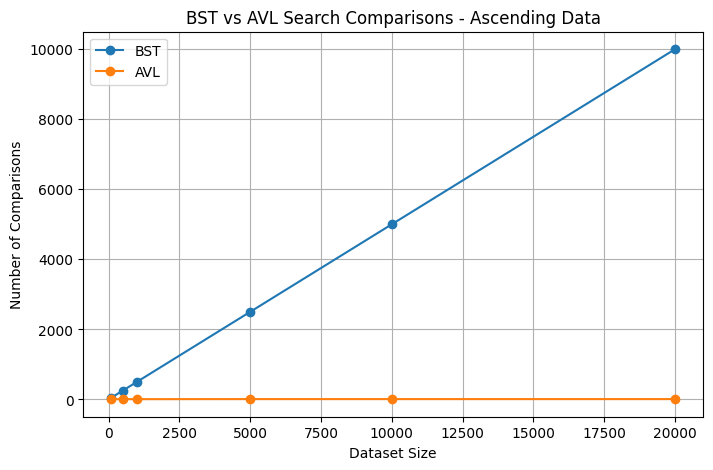

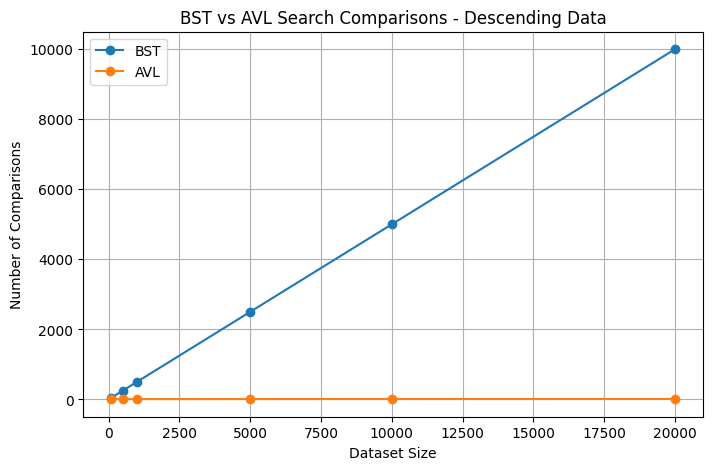

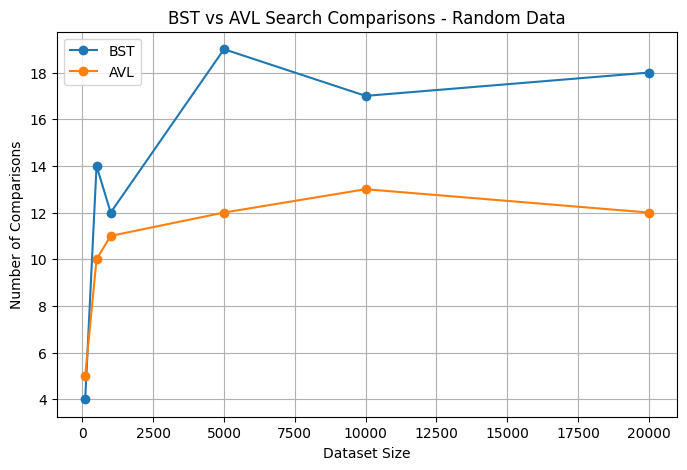

In [ ]:
import matplotlib.pyplot as plt

orders = ["ascending", "descending", "random"]

for order in orders:

    data = search_results[
        search_results["Order"] == order
    ]

    plt.figure(figsize=(8, 5))

    plt.plot(
        data["Size"],
        data["BST Comparisons"],
        marker="o",
        label="BST"
    )

    plt.plot(
        data["Size"],
        data["AVL Comparisons"],
        marker="o",
        label="AVL"
    )

    plt.xlabel("Dataset Size")
    plt.ylabel("Number of Comparisons")

    plt.title(
        f"BST vs AVL Search Comparisons - {order.capitalize()} Data"
    )

    plt.legend()
    plt.grid(True)

    plt.show()

In [ ]:
final_results = pd.merge(
    results,
    search_results,
    on=["Order", "Size"]
)

final_results = final_results[
    [
        "Size",
        "Order",
        "BST Height",
        "AVL Height",
        "BST Insert Time",
        "AVL Insert Time",
        "BST Comparisons",
        "AVL Comparisons"
    ]
]

final_results = final_results.sort_values(
    ["Order", "Size"]
)

final_results

,Size,Order,BST Height,AVL Height,BST Insert Time,AVL Insert Time,BST Comparisons,AVL Comparisons
0,100,ascending,100,7,0.000036,0.000025,50,6
1,500,ascending,500,9,0.000837,0.000146,250,8
2,1000,ascending,1000,10,0.003128,0.000327,500,8
3,5000,ascending,5000,13,0.079709,0.002010,2500,10
4,10000,ascending,10000,14,0.318716,0.004433,5000,10
5,20000,ascending,20000,15,1.273368,0.009854,10000,10
6,100,descending,100,7,0.000035,0.000024,51,7
7,500,descending,500,9,0.000734,0.000138,251,9
8,1000,descending,1000,10,0.002910,0.000332,501,10
9,5000,descending,5000,13,0.073091,0.001993,2501,12


In [ ]:
final_results.to_csv(
    "final_avl_bst_experiment.csv",
    index=False
)

print("Final experimental results saved!")

Final experimental results saved!


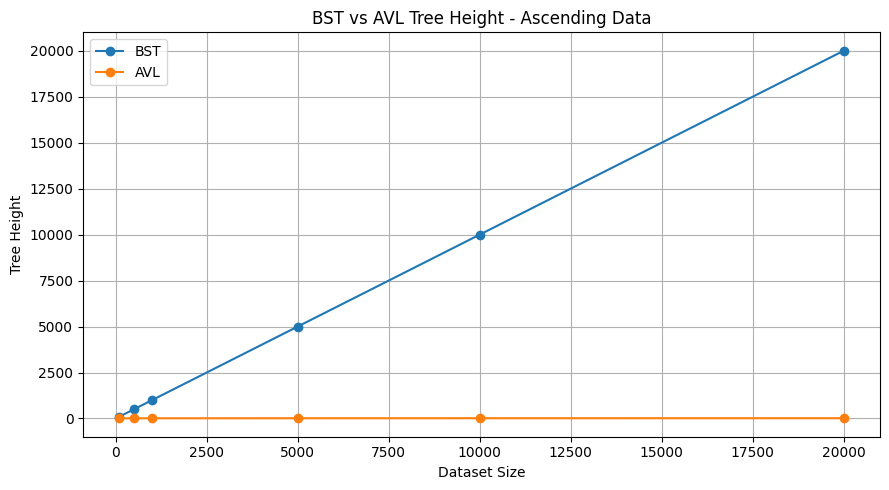

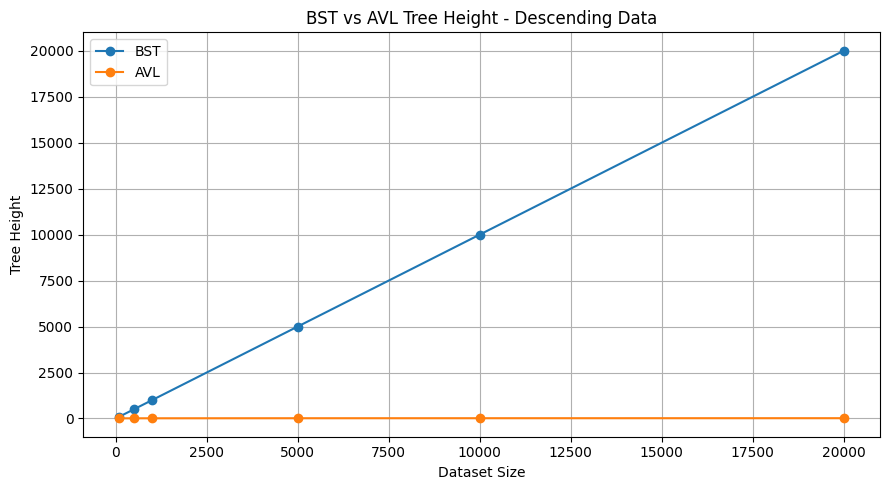

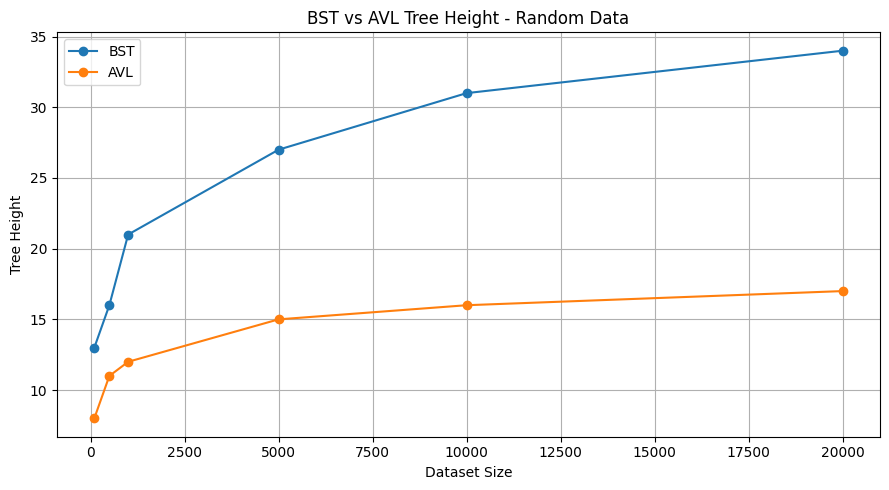

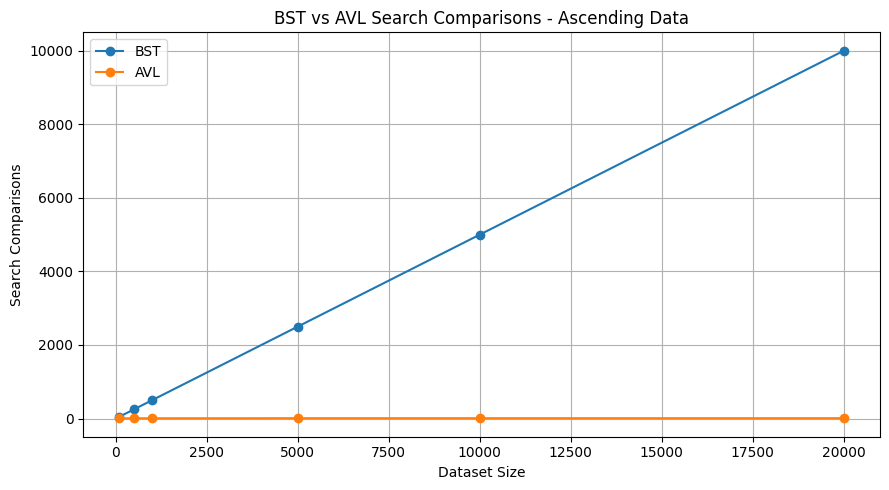

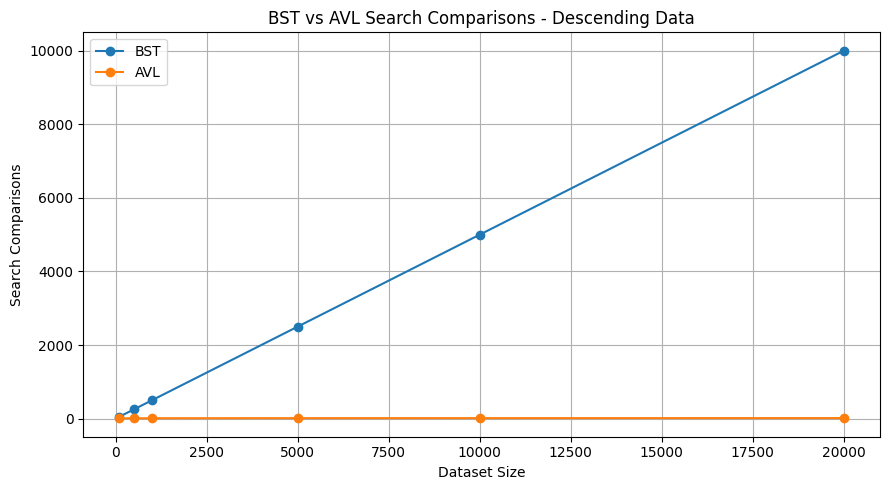

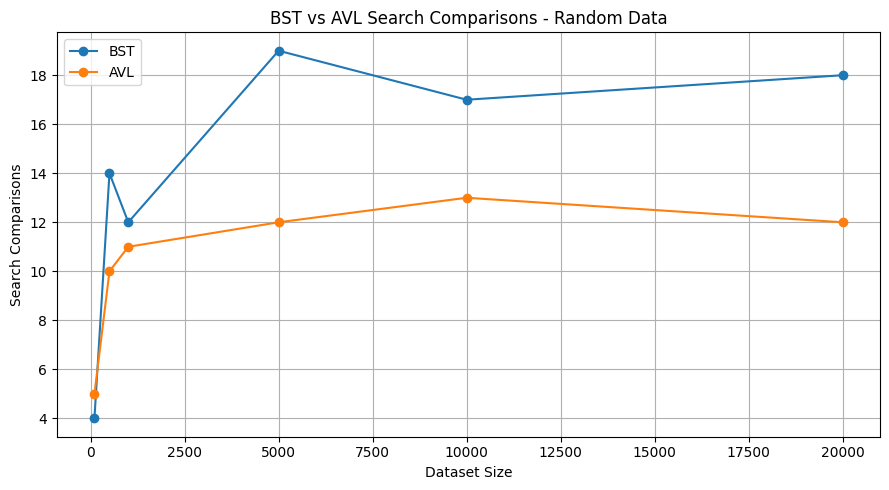

All graphs created successfully!


In [ ]:
import matplotlib.pyplot as plt

orders = ["ascending", "descending", "random"]

# ---------- Graph 1: Tree Height ----------
for order in orders:

    data = final_results[
        final_results["Order"] == order
    ]

    plt.figure(figsize=(9, 5))

    plt.plot(
        data["Size"],
        data["BST Height"],
        marker="o",
        label="BST"
    )

    plt.plot(
        data["Size"],
        data["AVL Height"],
        marker="o",
        label="AVL"
    )

    plt.xlabel("Dataset Size")
    plt.ylabel("Tree Height")
    plt.title(
        f"BST vs AVL Tree Height - {order.capitalize()} Data"
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    filename = f"height_{order}.png"
    plt.savefig(filename, dpi=300)
    plt.show()


# ---------- Graph 2: Search Comparisons ----------
for order in orders:

    data = final_results[
        final_results["Order"] == order
    ]

    plt.figure(figsize=(9, 5))

    plt.plot(
        data["Size"],
        data["BST Comparisons"],
        marker="o",
        label="BST"
    )

    plt.plot(
        data["Size"],
        data["AVL Comparisons"],
        marker="o",
        label="AVL"
    )

    plt.xlabel("Dataset Size")
    plt.ylabel("Search Comparisons")
    plt.title(
        f"BST vs AVL Search Comparisons - {order.capitalize()} Data"
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    filename = f"search_{order}.png"
    plt.savefig(filename, dpi=300)
    plt.show()


print("All graphs created successfully!")

In [ ]:
from google.colab import files

graph_files = [
    "height_ascending.png",
    "height_descending.png",
    "height_random.png",
    "search_ascending.png",
    "search_descending.png",
    "search_random.png"
]

for file in graph_files:
    files.download(file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Find the 20,000-element results
large_data = final_results[
    final_results["Size"] == 20000
]

print("===== 20,000 ELEMENT COMPARISON =====")
print(large_data.to_string(index=False))

print("\n===== KEY HEIGHT DIFFERENCES =====")

for order in ["ascending", "descending", "random"]:

    row = final_results[
        (final_results["Size"] == 20000) &
        (final_results["Order"] == order)
    ].iloc[0]

    print(
        f"{order.capitalize()}: "
        f"BST Height = {row['BST Height']}, "
        f"AVL Height = {row['AVL Height']}"
    )

===== 20,000 ELEMENT COMPARISON =====
 Size      Order  BST Height  AVL Height  BST Insert Time  AVL Insert Time  BST Comparisons  AVL Comparisons
20000  ascending       20000          15         1.273368         0.009854            10000               10
20000 descending       20000          15         1.177447         0.009601            10001               14
20000     random          34          17         0.005605         0.012647               18               12

===== KEY HEIGHT DIFFERENCES =====
Ascending: BST Height = 20000, AVL Height = 15
Descending: BST Height = 20000, AVL Height = 15
Random: BST Height = 34, AVL Height = 17
